# **Variational Quantum Classifier (VQC)**


 ## **Workflow**

- **Creating the local environment with the required development packages**
- **Import Qiskit libraries**
- **Load MRI data**
- **Dimensionality reduction using PCA and Scaling**
- **Selecting a feature encoder**
- **Selecting an Ansatz**
- **Optimizer**
- **VQC model construction**
- **Training**
- **Testing**
- **Evaluation of model performance**


## Building VQC  model 

In [6]:
import qiskit
import qiskit_machine_learning
import qiskit_aer
import qiskit_algorithms

print("Qiskit:", qiskit.__version__)
print("Qiskit ML:", qiskit_machine_learning.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit Algorithms:", qiskit_algorithms.__version__)

Qiskit: 1.2.4
Qiskit ML: 0.7.2
Qiskit Aer: 0.14.2
Qiskit Algorithms: 0.3.0


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from qiskit.circuit.library import ZZFeatureMap, ExcitationPreserving
from qiskit_algorithms.optimizers import COBYLA

from qiskit_machine_learning.algorithms.classifiers import VQC


# SETTINGS

N_TRAIN = 5700

N_PCA = 4

SEED = 42


# LOAD DATA

X_train = np.load("data_Demo/X_train.npy")
y_train = np.load("data_Demo/y_train.npy")

X_test = np.load("data_Demo/X_test.npy")
y_test = np.load("data_Demo/y_test.npy")



print("Training pool:", X_train.shape)
print("Test set:", X_test.shape)

print("\nOriginal training distribution:")
print(np.bincount(y_train))

print("\nTest distribution:")
print(np.bincount(y_test))


# SELECT TRAINING SAMPLES


idx = np.arange(len(X_train))

idx_train, _ = train_test_split(
    idx,
    train_size=N_TRAIN,
    stratify=y_train,
    random_state=SEED
)

X_train = X_train[idx_train]
y_train = y_train[idx_train]


print("\nSelected training distribution:")
print(np.bincount(y_train))

print("Selected training samples:", X_train.shape)


# PCA 

pca = PCA(n_components=N_PCA)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# SCALE TO [0, π] 

scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Reduced train shape:", X_train.shape)
print("Reduced test shape:", X_test.shape)

# NUMBER of QUBITS

num_qubits = N_PCA

print("Number of qubits:", num_qubits)

# FEATURE MAP
feature_map = ZZFeatureMap(
    feature_dimension=num_qubits,
    reps=1
)

# ANSATZ

#ansatz = EfficientSU2(num_qubits=num_qubits,reps=5,entanglement="full")
#ansatz = EfficientSU2(num_qubits=num_qubits, reps=7, entanglement="full")
#ansatz = EfficientSU2(num_qubits=4,reps=7,entanglement="reverse_linear")
#ansatz = TwoLocal(num_qubits=4,rotation_blocks=['ry', 'rz'],entanglement_blocks='cx',entanglement='full',reps=7)


ansatz = ExcitationPreserving(
    num_qubits=num_qubits,
    reps=7,
    entanglement="full"
)


# OPTIMIZER

optimizer = COBYLA(maxiter=300)
#optimizer = COBYLA(maxiter=1000)
#optimizer = COBYLA(maxiter=1200)


# CALLBACK

objective_values = []
best_loss = float("inf")
best_weights = None

def callback(weights, objective):
    global best_loss, best_weights

    objective_values.append(objective)

    if len(objective_values) % 10 == 0:
        print(f"Iteration {len(objective_values)} Loss = {objective:.6f}")

    if objective < best_loss:
        best_loss = objective
        best_weights = np.copy(weights)

# Building VQC MODEL

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

# TRAIN

print("\nTraining...\n")
vqc.fit(X_train, y_train)

# Testing

y_pred = vqc.predict(X_test)

# RESULTS

print("\nAccuracy =", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# SAVE BEST PARAMETERS
np.save("Demo_best_VQC_weights.npy", best_weights)
print("Best loss:", best_loss)

Training pool: (5712, 128)
Test set: (1311, 128)

Original training distribution:
[1321 1339 1595 1457]

Test distribution:
[300 306 405 300]

Selected training distribution:
[1318 1336 1592 1454]
Selected training samples: (5700, 128)
Reduced train shape: (5700, 4)
Reduced test shape: (1311, 4)
Number of qubits: 4

Training...

Iteration 10 Loss = 2.336576
Iteration 20 Loss = 1.983524
Iteration 30 Loss = 1.984849
Iteration 40 Loss = 1.819424
Iteration 50 Loss = 2.003276
Iteration 60 Loss = 1.991694
Iteration 70 Loss = 1.773841
Iteration 80 Loss = 1.858004
Iteration 90 Loss = 1.494066
Iteration 100 Loss = 1.526136
Iteration 110 Loss = 1.432488
Iteration 120 Loss = 1.471617
Iteration 130 Loss = 1.524706
Iteration 140 Loss = 1.422876
Iteration 150 Loss = 1.382232
Iteration 160 Loss = 1.464045
Iteration 170 Loss = 1.327546
Iteration 180 Loss = 1.304069
Iteration 190 Loss = 1.277340
Iteration 200 Loss = 1.247464
Iteration 210 Loss = 1.235843
Iteration 220 Loss = 1.191658
Iteration 230 Loss

In [8]:
np.save("Objective_Demo_COBYLA300.npy", objective_values)


<Figure size 700x600 with 0 Axes>

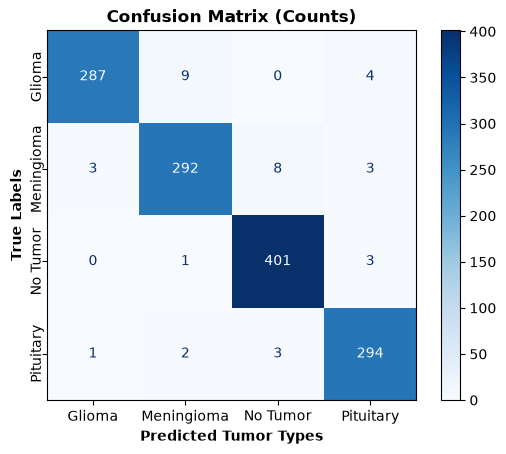

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=CLASS_NAMES)

disp.plot(cmap="Blues", 
          values_format="d")

for label in disp.ax_.get_yticklabels():
    label.set_rotation(90)
    label.set_verticalalignment("center")
    label.set_horizontalalignment("center")

plt.title("Confusion Matrix (Counts)", fontweight="bold")
plt.xlabel("Predicted Tumor Types", fontweight="bold")
plt.ylabel("True Labels", fontweight="bold")

plt.show()

## Confusion matrix with percentages

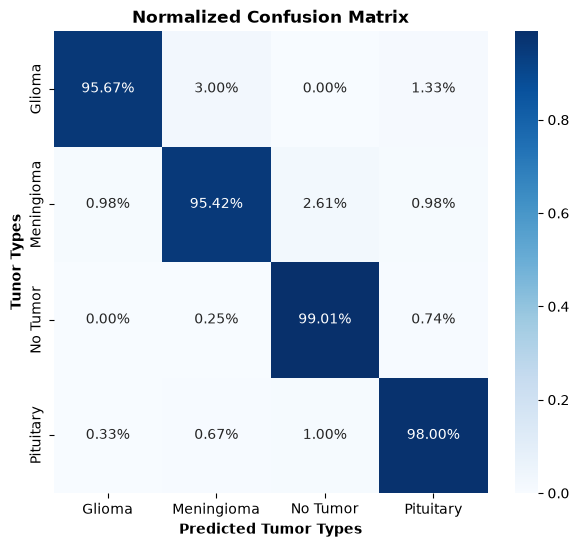

In [24]:
import numpy as np
import seaborn as sns

cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Tumor Types", fontweight="bold")
plt.ylabel("Tunor Types", fontweight="bold")
plt.title("Normalized Confusion Matrix", fontweight="bold")

plt.show()

## Classification report

In [27]:
print(
        classification_report(
            y_test,
            y_pred,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

              precision    recall  f1-score   support

      Glioma       0.99      0.96      0.97       300
  Meningioma       0.96      0.95      0.96       306
    No Tumor       0.97      0.99      0.98       405
   Pituitary       0.97      0.98      0.97       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



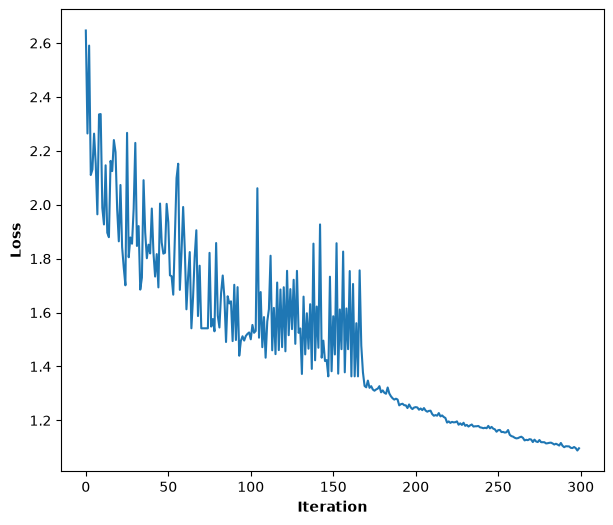

In [26]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(objective_values)
plt.xlabel("Iteration", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.show()

# PCA Components and classical SVM Performance

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# SETTINGS

N_TRAIN = 5700

PCA_RANGE = range(2, 17)

SEED = 42


# LOAD DATA

X_train = np.load("data_Demo/X_train.npy")
y_train = np.load("data_Demo/y_train.npy")

X_test = np.load("data_Demo/X_test.npy")
y_test = np.load("data_Demo/y_test.npy")




print("Training pool:", X_train.shape)
print("Test set:", X_test.shape)

print("\nOriginal training distribution:")
print(np.bincount(y_train))

print("\nTest distribution:")
print(np.bincount(y_test))


# SELECT TRAINING SAMPLES 


idx = np.arange(len(X_train))

idx_train, _ = train_test_split(
    idx,
    train_size=N_TRAIN,
    stratify=y_train,
    random_state=SEED
)

X_train = X_train[idx_train]
y_train = y_train[idx_train]


print("\nSelected training distribution:")
print(np.bincount(y_train))

print("Selected training samples:", X_train.shape)


# PCA + SVM SWEEP

results = []

print("\n")
print("-" * 70)
print("PCA + RBF-SVM RESULTS")
print("-" * 70)

print(
    f"{'PCA':>5} | "
    f"{'Explained Variance':>20} | "
    f"{'Test Accuracy':>15}"
)

print("-" * 70)


for n_pca in PCA_RANGE:

    # PCA

    pca = PCA(
        n_components=n_pca
    )

    X_train_pca = pca.fit_transform(
        X_train
    )

    X_test_pca = pca.transform(
        X_test
    )


    # Explained variance

    explained_variance = (
        pca.explained_variance_ratio_.sum()
    )


    # RBF SVM

    svm = SVC(
        kernel="rbf"
    )

    svm.fit(
        X_train_pca,
        y_train
    )


    # Prediction

    pred = svm.predict(
        X_test_pca
    )


    # Accuracy

    accuracy = accuracy_score(
        y_test,
        pred
    )


    # Store results

    results.append({
        "PCA": n_pca,
        "Explained_Variance": explained_variance,
        "Accuracy": accuracy
    })


    # Print result

    print(
        f"{n_pca:5d} | "
        f"{explained_variance * 100:19.2f}% | "
        f"{accuracy * 100:14.2f}%"
    )


# CONVERT RESULTS TO DATAFRAME

import pandas as pd

results_df = pd.DataFrame(results)


Training pool: (5712, 128)
Test set: (1311, 128)

Original training distribution:
[1321 1339 1595 1457]

Test distribution:
[300 306 405 300]

Selected training distribution:
[1318 1336 1592 1454]
Selected training samples: (5700, 128)


----------------------------------------------------------------------
PCA + RBF-SVM RESULTS
----------------------------------------------------------------------
  PCA |   Explained Variance |   Test Accuracy
----------------------------------------------------------------------
    2 |               74.27% |          98.70%
    3 |               99.66% |          99.39%
    4 |               99.86% |          99.39%
    5 |               99.88% |          99.39%
    6 |               99.89% |          99.39%
    7 |               99.90% |          99.39%
    8 |               99.91% |          99.39%
    9 |               99.91% |          99.39%
   10 |               99.92% |          99.39%
   11 |               99.92% |          99.39%
   12 |   

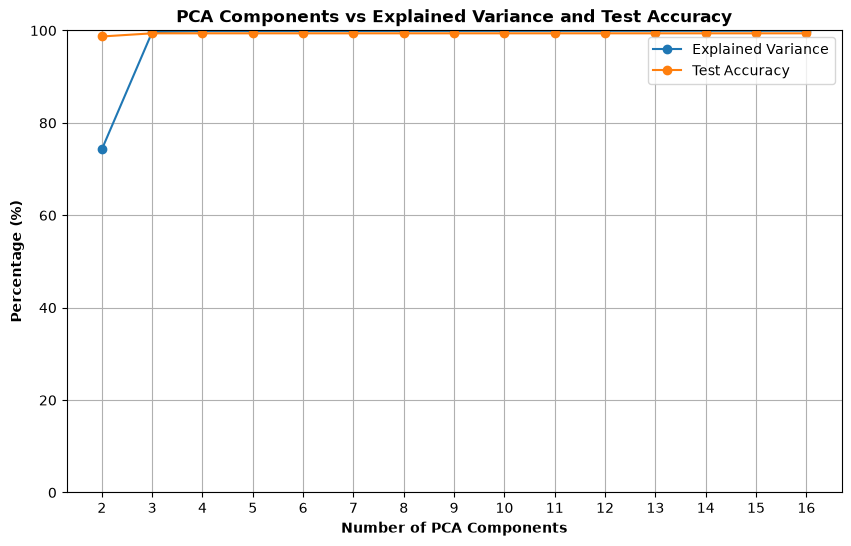

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["PCA"],
    results_df["Explained_Variance"] * 100,
    marker="o",
    label="Explained Variance"
)

plt.plot(
    results_df["PCA"],
    results_df["Accuracy"] * 100,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Number of PCA Components", fontweight="bold")
plt.ylabel("Percentage (%)", fontweight="bold")
plt.title("PCA Components vs Explained Variance and Test Accuracy", fontweight="bold")

plt.xticks(results_df["PCA"])
plt.ylim(0, 100)

plt.grid(True)
plt.legend()

plt.show()

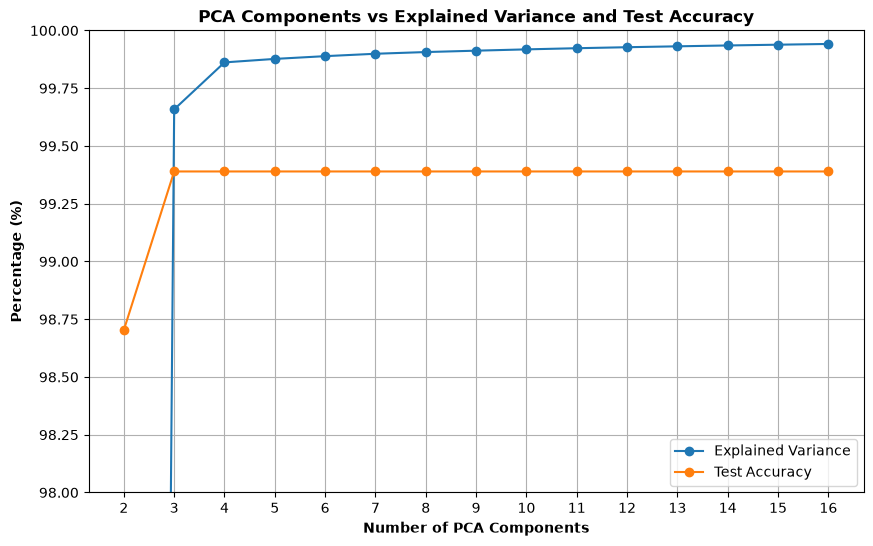

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["PCA"],
    results_df["Explained_Variance"] * 100,
    marker="o",
    label="Explained Variance"
)

plt.plot(
    results_df["PCA"],
    results_df["Accuracy"] * 100,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Number of PCA Components", fontweight="bold")
plt.ylabel("Percentage (%)", fontweight="bold")
plt.title("PCA Components vs Explained Variance and Test Accuracy", fontweight="bold")

plt.xticks(results_df["PCA"])
plt.ylim(98, 100)

plt.grid(True)
plt.legend()

plt.show()

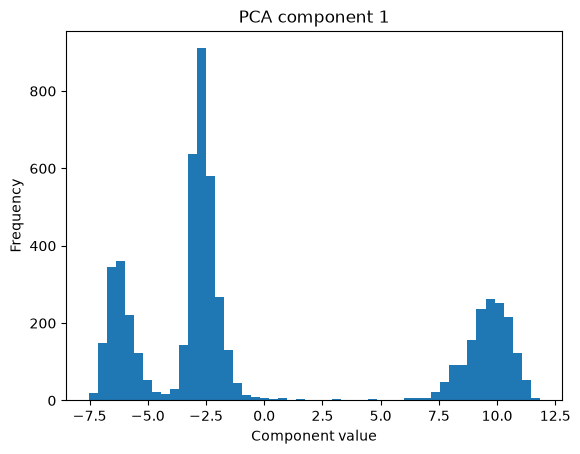

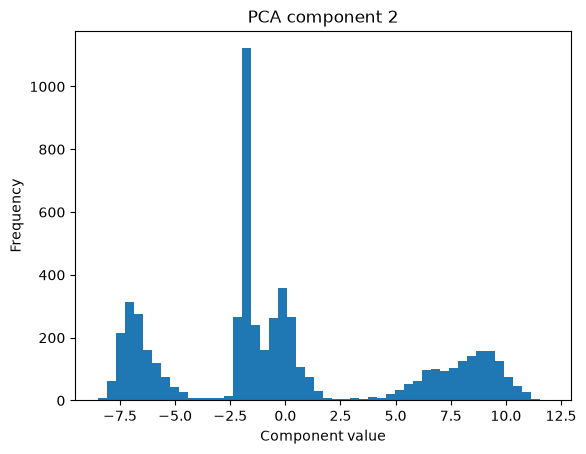

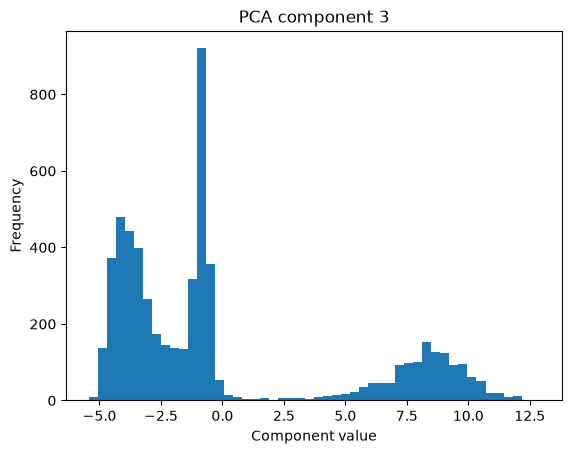

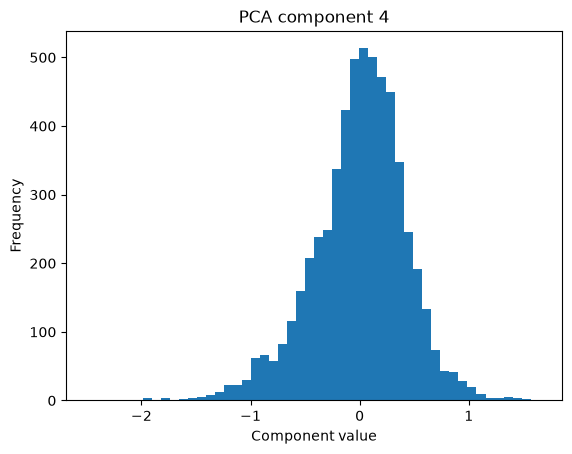

In [18]:
# PCA components

import matplotlib.pyplot as plt

N_PCA = 4

pca = PCA(n_components=N_PCA)

X_train_pca = pca.fit_transform(X_train)

for i in range(N_PCA):

    plt.hist(X_train_pca[:, i], bins=50)

    plt.title(f"PCA component {i + 1}")

    plt.xlabel("Component value")
    plt.ylabel("Frequency")

    plt.show()


PCA explained variance:
PC1: 42.42%
PC2: 31.84%
PC3: 25.39%
PC4: 0.20%

Total variance explained by PC1-PC4: 99.86%


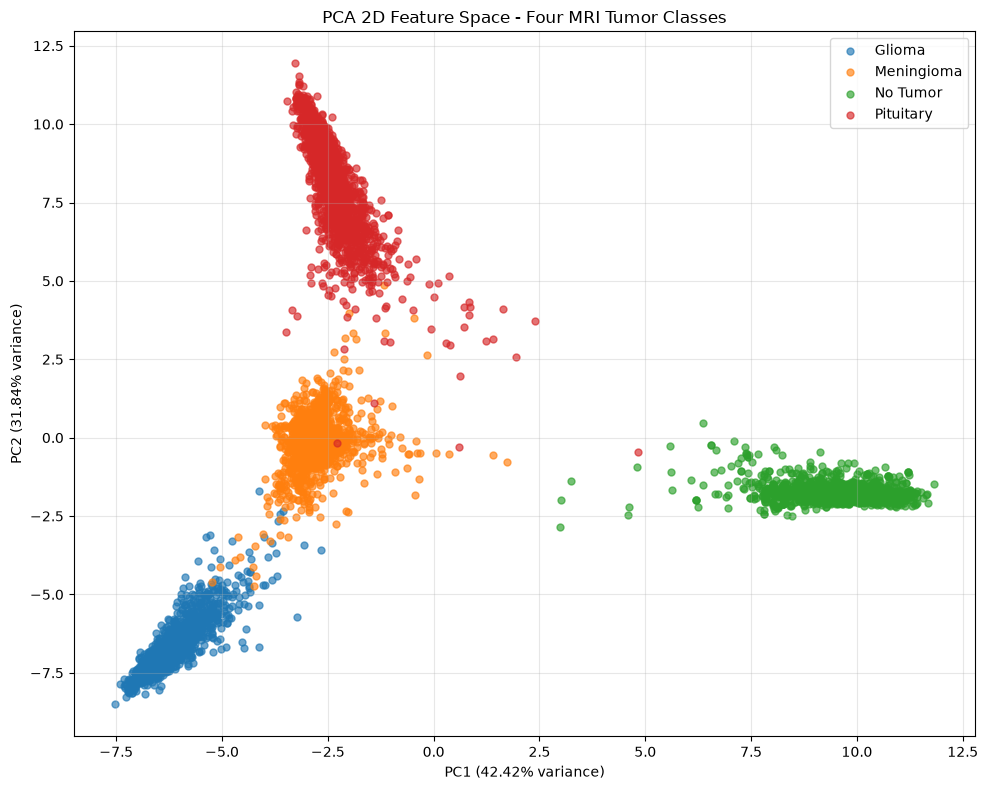

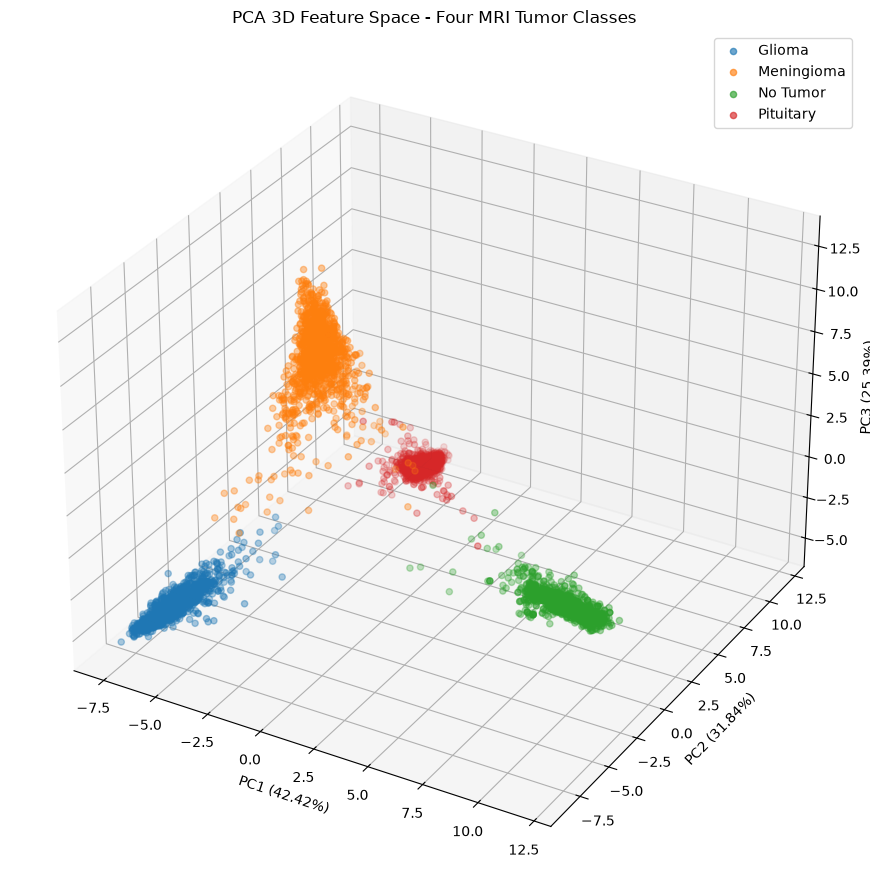

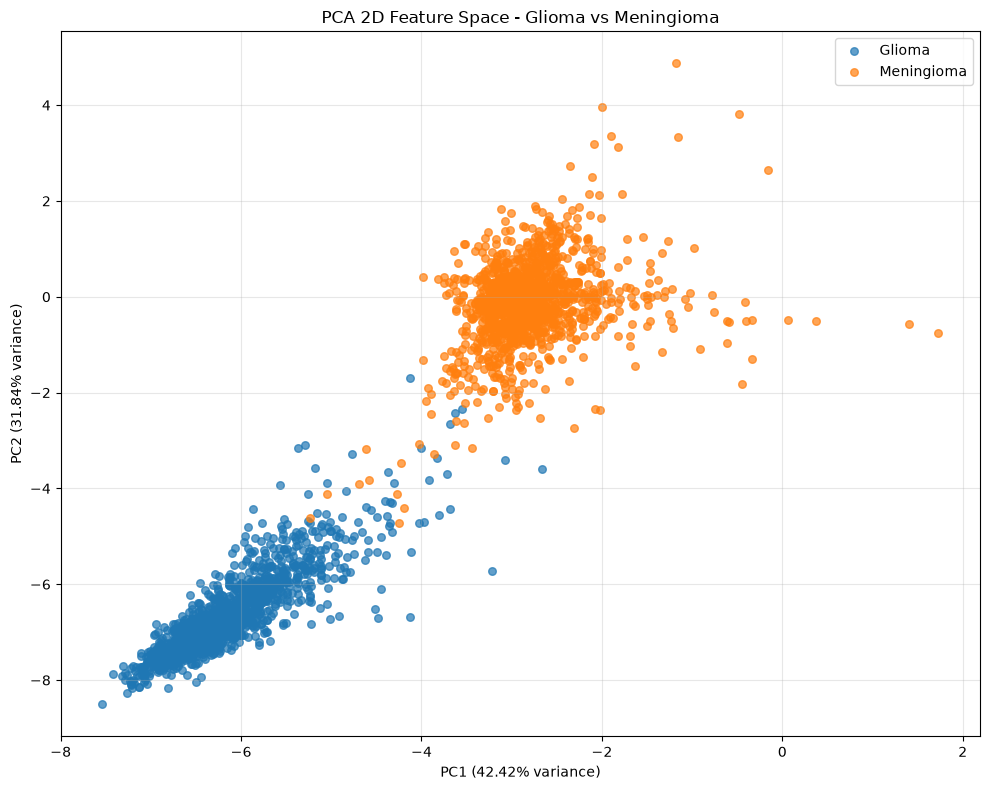

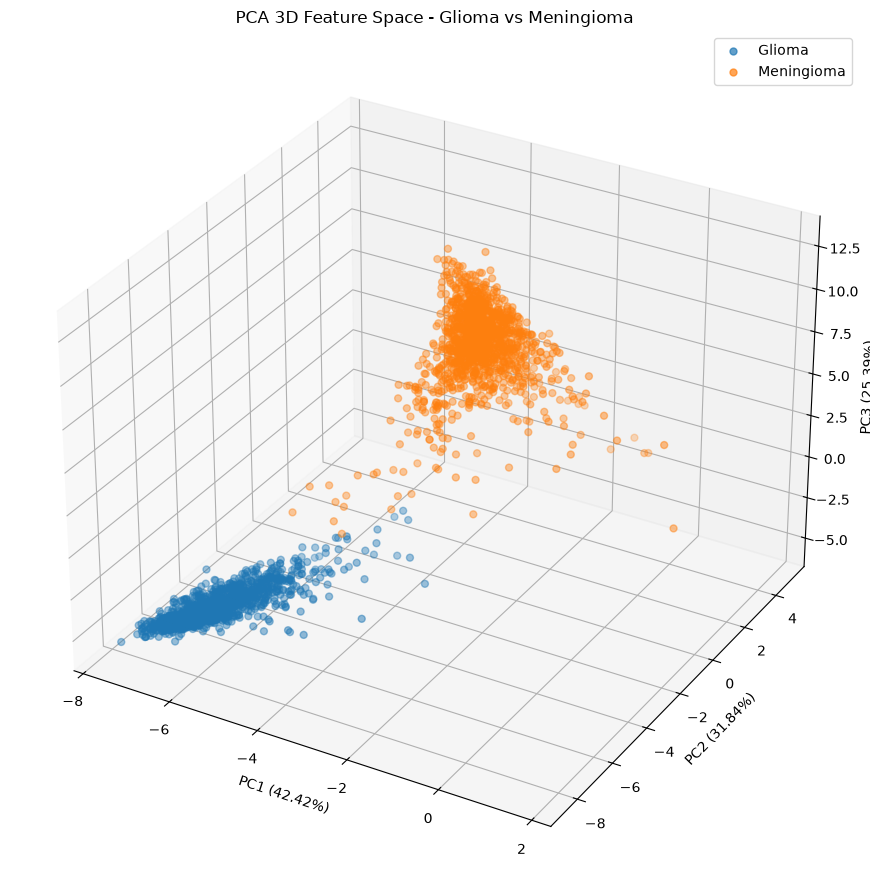

In [ ]:
# Visualization of PCA components of the Training set

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


# ============================================================
# 1. SETTINGS
# ============================================================

N_TRAIN = 5700
N_PCA = 4

CLASS_NAMES = {
    0: "Glioma",
    1: "Meningioma",
    2: "No Tumor",
    3: "Pituitary"
}




# ============================================================
# 5. EXPLAINED VARIANCE
# ============================================================

print("\nPCA explained variance:")

for i, variance in enumerate(pca.explained_variance_ratio_):
    print(
        f"PC{i+1}: {variance * 100:.2f}%"
    )

print(
    f"\nTotal variance explained by "
    f"PC1-PC{N_PCA}: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)


# ============================================================
# 6. 2D PCA - ALL FOUR CLASSES
# ============================================================

plt.figure(figsize=(10, 8))

for class_id, class_name in CLASS_NAMES.items():

    mask = y_train == class_id

    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=class_name,
        alpha=0.65,
        s=25
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.title("PCA 2D Feature Space - Four MRI Tumor Classes")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "PCA_2D_four_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 7. 3D PCA - ALL FOUR CLASSES

fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(111, projection="3d")

for class_id, class_name in CLASS_NAMES.items():

    mask = y_train == class_id

    ax.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        X_train_pca[mask, 2],
        label=class_name,
        alpha=0.65,
        s=20
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

ax.set_zlabel(
    f"PC3 ({pca.explained_variance_ratio_[2] * 100:.2f}%)"
)

ax.set_title("PCA 3D Feature Space - Four MRI Tumor Classes")

ax.legend()

plt.tight_layout()

plt.savefig(
    "PCA_3D_four_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 8. GLIOMA vs MENINGIOMA - 2D

binary_mask = np.isin(y_train, [0, 1])

X_gm = X_train_pca[binary_mask]
y_gm = y_train[binary_mask]

plt.figure(figsize=(10, 8))

for class_id in [0, 1]:

    mask = y_gm == class_id

    plt.scatter(
        X_gm[mask, 0],
        X_gm[mask, 1],
        label=CLASS_NAMES[class_id],
        alpha=0.70,
        s=30
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.title("PCA 2D Feature Space - Glioma vs Meningioma")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "PCA_2D_Glioma_vs_Meningioma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 9. GLIOMA vs MENINGIOMA - 3D

fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(111, projection="3d")

for class_id in [0, 1]:

    mask = y_gm == class_id

    ax.scatter(
        X_gm[mask, 0],
        X_gm[mask, 1],
        X_gm[mask, 2],
        label=CLASS_NAMES[class_id],
        alpha=0.70,
        s=25
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

ax.set_zlabel(
    f"PC3 ({pca.explained_variance_ratio_[2] * 100:.2f}%)"
)

ax.set_title("PCA 3D Feature Space - Glioma vs Meningioma")

ax.legend()

plt.tight_layout()

plt.savefig(
    "PCA_3D_Glioma_vs_Meningioma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()